# **Data Preprocessing and Exploratory Data Analysis**

#**1. Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ydata-profiling
from ydata_profiling import ProfileReport
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
file_name = 'paper_2023.xlsx'
df0 = pd.read_excel(file_name, sheet_name='paper')
pd.set_option("display.max_columns", None)

display(df0.head(3))

,InspectionID,Reporting Country,Port of Inspection,DateOfFirstVisit,DateOfFinalVisit,Duration,Type of Inspection,Ship_IMO,Ship_Name,Ship Flag,Flag Performance List,Flag Performance List NUM,Type of Ship,Description,KeelDate,Ship Age,Ship_CallSign,Gross Tonnage,Class_Authority,Class_Status,Recognised Organisation (RO),RO Performance List,RO Performance List NUM,RO_Type,Detention < 36 months,Deficiency_Count,IsDetained,GroundsForDetention_Codes,Total Defficiencies in 36months,Mean of Defficiencies in 36months,GroundsForDetention,SUM of GroundsForDetention in 36months,MEAN of GroundsForDetention in 36months
0,4239515394,NO,NOMJF,2023-01-02 02:00:00,2023-01-02 02:00:00,0.0,INITIAL_INSPECTION,9505572.0,WARNOWBORG,NL,W,0,360,Warship and naval auxiliary,2008-12-30 02:00:00,15,PCBT,6668,115.0,DELIVERED,115,H,0.0,RO,0,0,0,NaN,2,2.0,0.0,0,0.0
1,4246340630,NL,NLAMS,2023-01-02 02:00:00,2023-01-02 02:00:00,0.0,DETAILED_INSPECTION,9499436.0,ORCUN C,PA,G,1,360,Warship and naval auxiliary,2010-12-29 02:00:00,13,3FVP6,19815,186.0,DELIVERED,169,H,0.0,RO,0,4,0,NaN,1,1.0,0.0,0,0.0
2,4246341017,NL,NLRTM,2023-01-02 02:00:00,2023-01-02 02:00:00,0.0,DETAILED_INSPECTION,9706774.0,IOANNIS K,LR,W,0,340,Warship and naval auxiliary,2015-12-02 02:00:00,8,D5RO9,44192,121.0,DELIVERED,121,H,0.0,RO,0,9,0,NaN,1,1.0,0.0,0,0.0


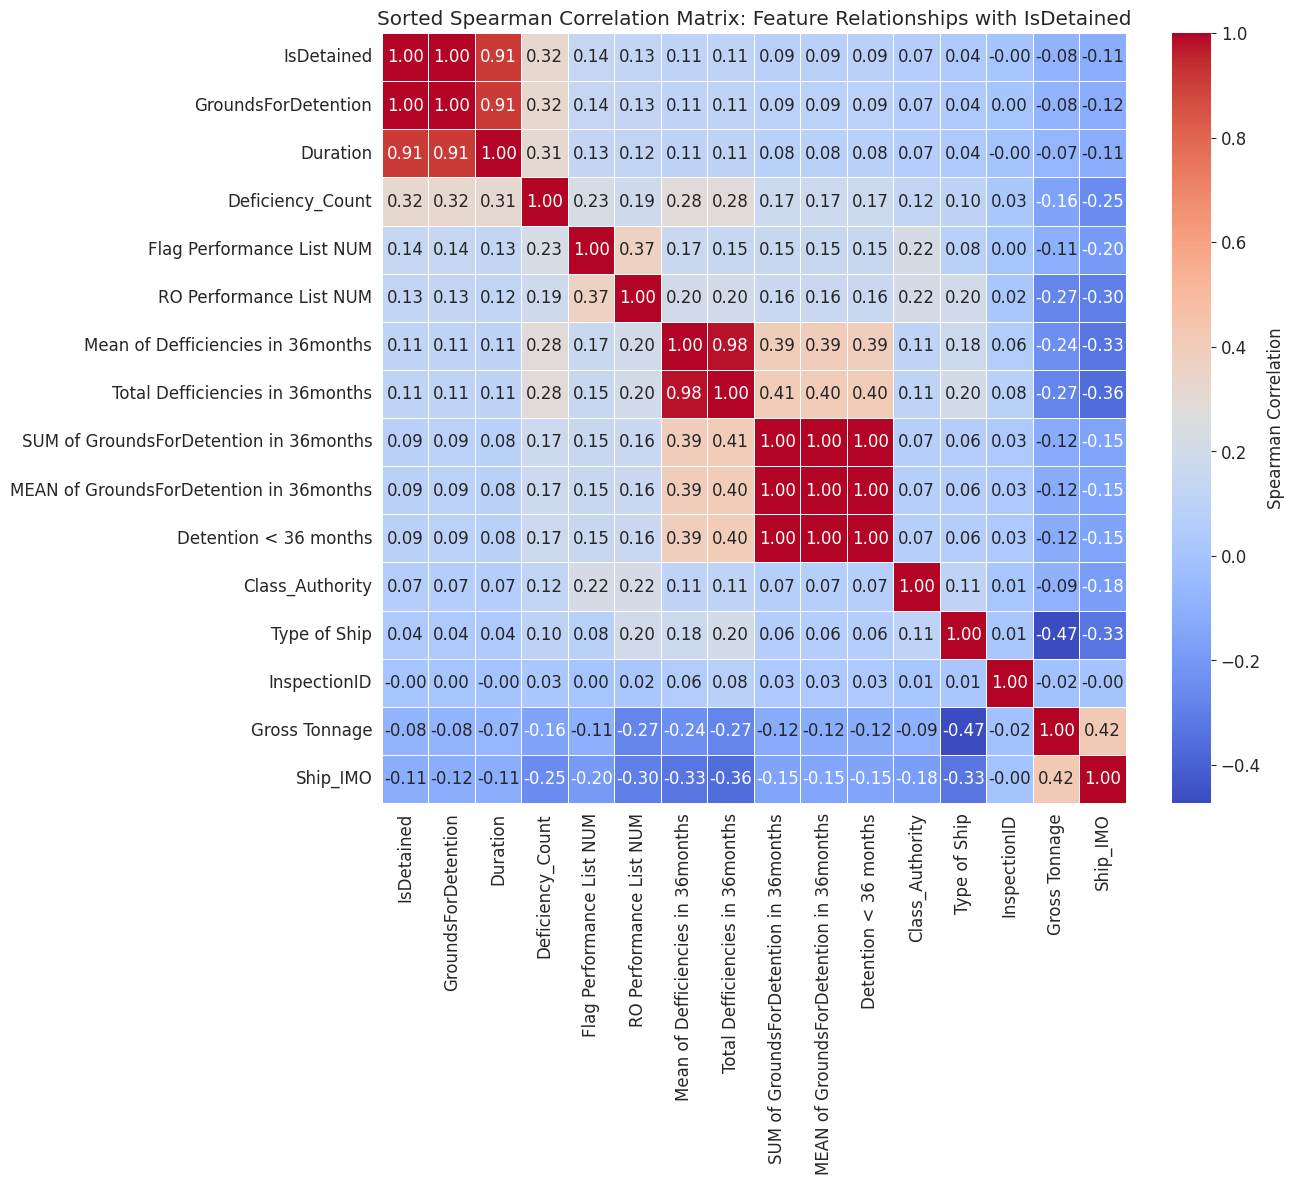

In [ ]:
num_cols = df0.select_dtypes(include=['number']).columns
corr_matrix = df0[num_cols].corr(method='spearman')


sorted_indices = corr_matrix['IsDetained'].sort_values(ascending=False).index
corr_sorted = corr_matrix.loc[sorted_indices, sorted_indices]

plt.figure(figsize=(12, 10))

sns.heatmap(corr_sorted,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': 'Spearman Correlation'})

plt.title('Sorted Spearman Correlation Matrix: Feature Relationships with IsDetained')
plt.show()

# **2. Data Cleaning and Preprocessing**

Before proceeding to the data cleaning and preprocessing phase, it is necessary to limit our dataset to those variables that possess predictive power for our model.

At this stage, we exclude:
- **Identifying information** (e.g., `InspectionID`, `Ship_IMO`, `Ship_Name`, `Ship_CallSign`)
- **Dates** (e.g., `DateOfFirstVisit`, `KeelDate`)
- **Redundant information**: Columns that describe the same thing in a different way (e.g., `Ship Flag`, `MEAN of GroundsForDetention in 36months`, `Mean of Defficiencies in 36months`)
- **Data Leakage:** This includes columns such as the duration (`Duration`) and the type of inspection (`Type of Inspection`), which cannot possibly be known to us prior to the inspection

In [ ]:
features_to_keep = [
    'Reporting Country',
    'Port of Inspection',
    'Ship Flag',
    'Flag Performance List NUM',
    'Description',
    'Ship Age',
    'Gross Tonnage',
    'Recognised Organisation (RO)',
    'RO Performance List NUM',
    'Detention < 36 months',
    'Deficiency_Count',
    'Total Defficiencies in 36months',
    'SUM of GroundsForDetention in 36months',
    'IsDetained'
]

df = df0[features_to_keep]

In [ ]:
print('Missing Values: \n')
print(df.isna().sum(), '\n')

print('Duplicate Values: ', df.duplicated().sum())

Missing Values: 

Reporting Country                          0
Port of Inspection                         0
Ship Flag                                  2
Flag Performance List NUM                  0
Description                                0
Ship Age                                   0
Gross Tonnage                              0
Recognised Organisation (RO)              14
RO Performance List NUM                   23
Detention < 36 months                      0
Deficiency_Count                           0
Total Defficiencies in 36months            0
SUM of GroundsForDetention in 36months     0
IsDetained                                 0
dtype: int64 

Duplicate Values:  177


In [ ]:
df = df.dropna()
df = df.drop_duplicates()

print('NaNs and Duplicates deleted')

NaNs and Duplicates deleted


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16523 entries, 0 to 16724
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Reporting Country                       16523 non-null  object 
 1   Port of Inspection                      16523 non-null  object 
 2   Ship Flag                               16523 non-null  object 
 3   Flag Performance List NUM               16523 non-null  int64  
 4   Description                             16523 non-null  object 
 5   Ship Age                                16523 non-null  object 
 6   Gross Tonnage                           16523 non-null  int64  
 7   Recognised Organisation (RO)            16523 non-null  object 
 8   RO Performance List NUM                 16523 non-null  float64
 9   Detention < 36 months                   16523 non-null  int64  
 10  Deficiency_Count                        16523 non-null  int64  

### We will use `ProfileReport` from `ydata_profiling` for a fast visualization check and then we will proceed in more specific visualizations to explore our data.

In [ ]:
profile = ProfileReport(df, title="Pandas Profiling Report")
profile.to_notebook_iframe()

#### From the ProfileReport overview, it was observed that the variables `Port of Inspection`, `Reporting Country`, `Ship Flag`, and `Recognised Organisation (RO)` exhibit an extremely high number of unique values (High Cardinality). To prevent overfitting and reduce the model's dimensionality, we will retain the most frequently occurring values and merge the rest into the value "Other".

In [ ]:
columns_to_fix = [
    'Recognised Organisation (RO)',
    'Port of Inspection',
    'Reporting Country',
    'Ship Flag'
]

for col in columns_to_fix:
    # 1. Calculation of relative frequency and cumulative percentage
    counts = df[col].value_counts(normalize=True)
    cum_sum = counts.cumsum()

    # 2. Identification of categories belonging to the top 90%
    keep_categories = cum_sum[cum_sum <= 0.90].index.tolist()

    # We always add at least the first category if the first one is > 90%
    if not keep_categories:
        keep_categories = [counts.index[0]]

    df[col] = df[col].apply(lambda x: x if x in keep_categories else 'Other')

    new_dist = df[col].value_counts(normalize=True) * 100
    print(f"Updated Distribution for: {col}")
    print(f"Retained {len(keep_categories)} unique values + 'Other'")
    print(new_dist.tail(5))
    print("-" * 30)

Updated Distribution for: Recognised Organisation (RO)
Retained 10 unique values + 'Other'
Recognised Organisation (RO)
186    5.598257
132    3.613145
215    1.252799
158    1.192277
121    1.089391
Name: proportion, dtype: float64
------------------------------
Updated Distribution for: Port of Inspection
Retained 305 unique values + 'Other'
Port of Inspection
ISSTR    0.05447
ITTOA    0.05447
GBBLY    0.05447
ESSCI    0.05447
CABCO    0.05447
Name: proportion, dtype: float64
------------------------------
Updated Distribution for: Reporting Country
Retained 17 unique values + 'Other'
Reporting Country
DK    3.104763
SE    2.808207
PT    2.572172
BG    2.227198
LV    2.069842
Name: proportion, dtype: float64
------------------------------
Updated Distribution for: Ship Flag
Retained 29 unique values + 'Other'
Ship Flag
FR    0.605217
GI    0.593113
KY    0.581008
TG    0.532591
KN    0.520487
Name: proportion, dtype: float64
------------------------------


#### We will also replace the `Description` values with a single word that characterizes the ship type.

In [ ]:
ship_mapping = {
    'Warship and naval auxiliary': 'Warship',
    'Oil tanker': 'Tanker',
    'Oil tanker/Chemical tanker ': 'ChemicalTanker',
    'Other special activities': 'Special',
    'Combination carrier': 'ComboCarrier',
    'NLS tanker': 'NLSTanker'
}


df['Description'] = df['Description'].map(ship_mapping).fillna(df['Description'])


print(df['Description'].unique())

['Warship' 'Tanker' 'ChemicalTanker' 'Special' 'ComboCarrier' 'NLSTanker']


Fianlly, we transform `Ship Age` to numerical.

In [ ]:
df['Ship Age'] = pd.to_numeric(df['Ship Age'], errors='coerce')

### We check again for duplicates after data proprocessing

In [ ]:
print('Missing Values: \n')
print(df.isna().sum(), '\n')

print('Duplicate Values: ', df.duplicated().sum())

Missing Values: 

Reporting Country                         0
Port of Inspection                        0
Ship Flag                                 0
Flag Performance List NUM                 0
Description                               0
Ship Age                                  3
Gross Tonnage                             0
Recognised Organisation (RO)              0
RO Performance List NUM                   0
Detention < 36 months                     0
Deficiency_Count                          0
Total Defficiencies in 36months           0
SUM of GroundsForDetention in 36months    0
IsDetained                                0
dtype: int64 

Duplicate Values:  6


In [ ]:
df = df.dropna()
df2 = df.drop_duplicates()
print('NaNs and Duplicates deleted')

NaNs and Duplicates deleted


# **3. Exploration Data Analysis**

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

if 'DateOfFirstVisit' in df2.columns:
    df2['DateOfFirstVisit'] = pd.to_datetime(df2['DateOfFirstVisit'], errors='coerce')
    df2['YearMonth'] = df2['DateOfFirstVisit'].dt.to_period('M')

## Class Distribution



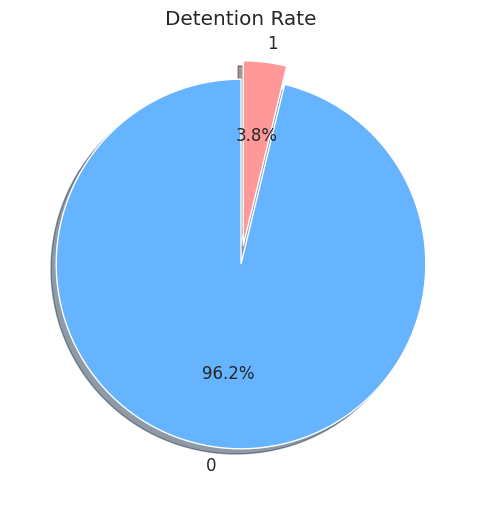

In [ ]:
plt.figure(figsize=(6, 6))

df2['IsDetained'].value_counts().plot.pie(autopct='%1.1f%%', explode=[0, 0.1], shadow=True, startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Detention Rate')
plt.ylabel('')
plt.show()

## Ship Age Distribution: Detained vs not Detained

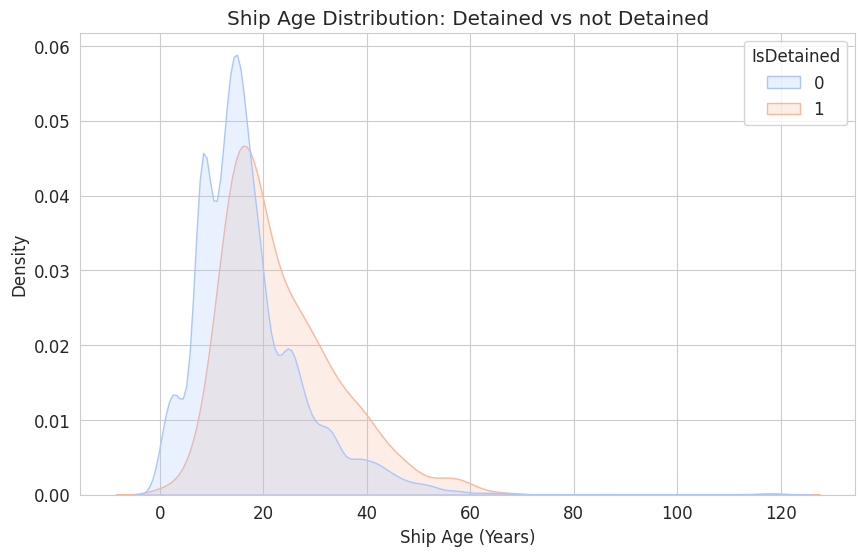

In [ ]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df2, x='Ship Age', hue='IsDetained', fill=True, common_norm=False, palette='coolwarm')
plt.title('Ship Age Distribution: Detained vs not Detained')
plt.xlabel('Ship Age (Years)')
plt.show()

## Probability of Detention by Ship Age

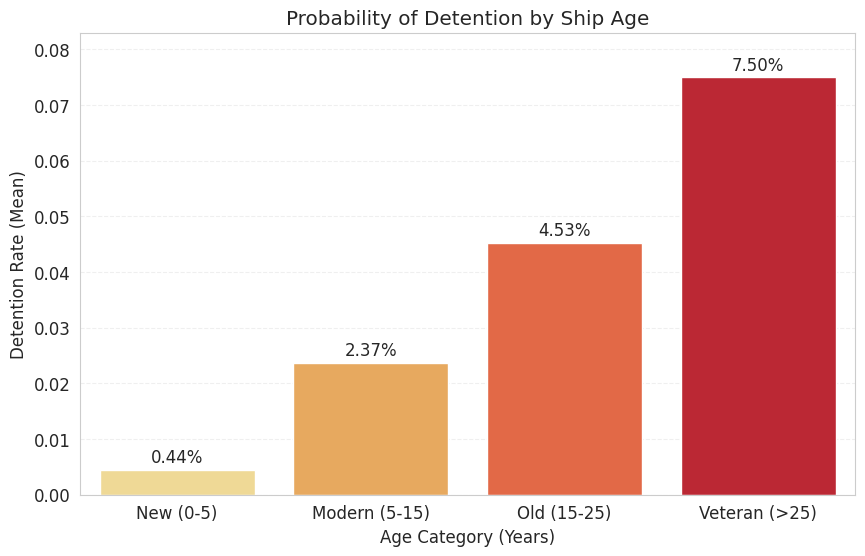

In [ ]:
bins_age = [0, 5, 15, 25, df2['Ship Age'].max() + 1]
labels_age = ['New (0-5)', 'Modern (5-15)', 'Old (15-25)', 'Veteran (>25)']

df2['Age_Category'] = pd.cut(df2['Ship Age'], bins=bins_age, labels=labels_age, include_lowest=True)


age_risk = df2.groupby('Age_Category', observed=True)['IsDetained'].mean().reset_index()


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=age_risk, x='Age_Category', y='IsDetained', palette='YlOrRd')


for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2%'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('Probability of Detention by Ship Age')
plt.ylabel('Detention Rate (Mean)')
plt.ylim([0, 0.083])
plt.xlabel('Age Category (Years)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [ ]:
print(df2.isna().sum())

Reporting Country                         0
Port of Inspection                        0
Ship Flag                                 0
Flag Performance List NUM                 0
Description                               0
Ship Age                                  0
Gross Tonnage                             0
Recognised Organisation (RO)              0
RO Performance List NUM                   0
Detention < 36 months                     0
Deficiency_Count                          0
Total Defficiencies in 36months           0
SUM of GroundsForDetention in 36months    0
IsDetained                                0
Age_Category                              0
dtype: int64


## Number of Deficiencies by Detention Status

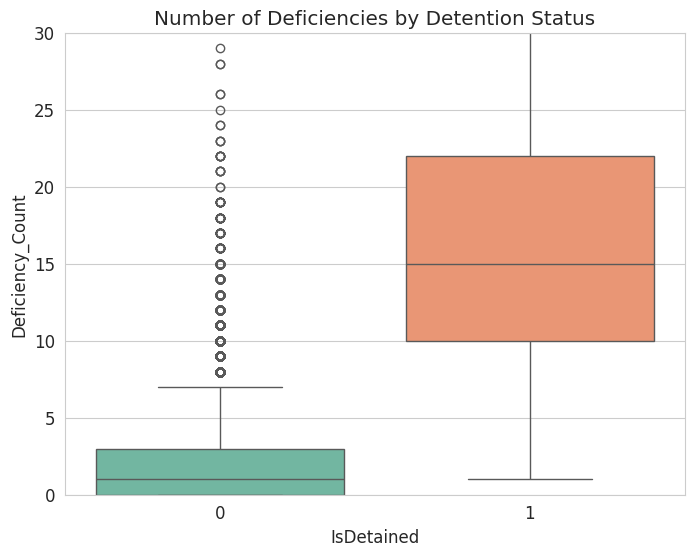

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df2, x='IsDetained', y='Deficiency_Count', palette='Set2')
plt.title('Number of Deficiencies by Detention Status')
plt.ylim(0, 30)
plt.show()

## Detention Probability by Flag Performance List (Flag Performance)

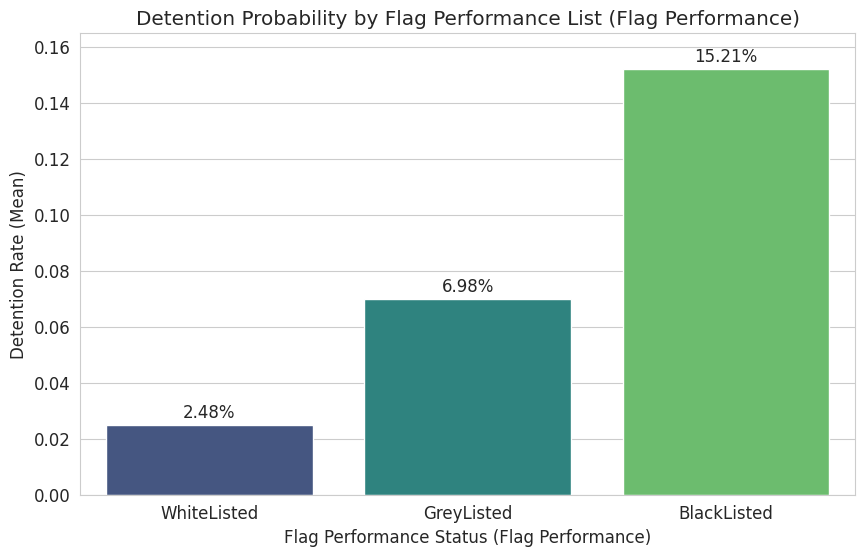

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df2,
    x='Flag Performance List NUM',
    y='IsDetained',
    palette='viridis',
    errorbar=None
)
plt.xticks(
    ticks=[0, 1, 2],
    labels=['WhiteListed', 'GreyListed', 'BlackListed']
)

plt.title('Detention Probability by Flag Performance List (Flag Performance)')
plt.xlabel('Flag Performance Status (Flag Performance)')
plt.ylabel('Detention Rate (Mean)')
plt.ylim([0, 0.165])

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2%'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

## Top 10 Ship Types with the Highest Detention Risk

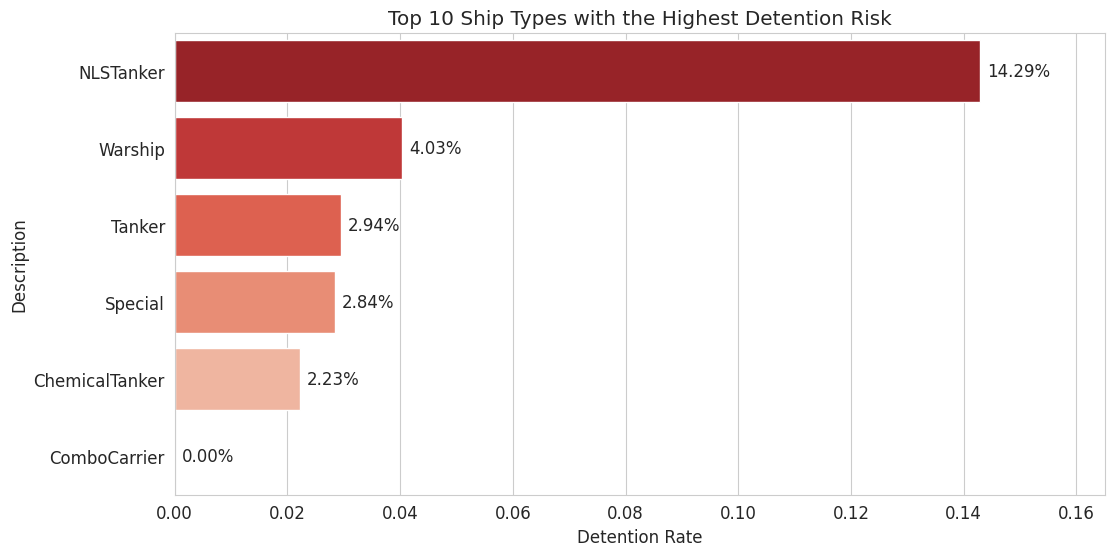

In [ ]:
type_risk = df2.groupby('Description')['IsDetained'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

# 1. Define ax here
ax = sns.barplot(x=type_risk.values, y=type_risk.index, palette='Reds_r')

plt.title('Top 10 Ship Types with the Highest Detention Risk')
plt.xlabel('Detention Rate')
plt.xlim([0, 0.165])

# 2. Correction for horizontal bars
for p in ax.patches:
    # In horizontal mode, the percentage is the width
    percentage = p.get_width()
    ax.annotate(format(percentage, '.2%'),
                (percentage, p.get_y() + p.get_height() / 2.),
                ha = 'left',      # Left alignment from the point
                va = 'center',    # Centered vertically
                xytext = (5, 0),  # Small distance of 5 pixels to the right of the bar
                textcoords = 'offset points')

plt.show()

## Ship Size (Log) vs Number of Deficiencies

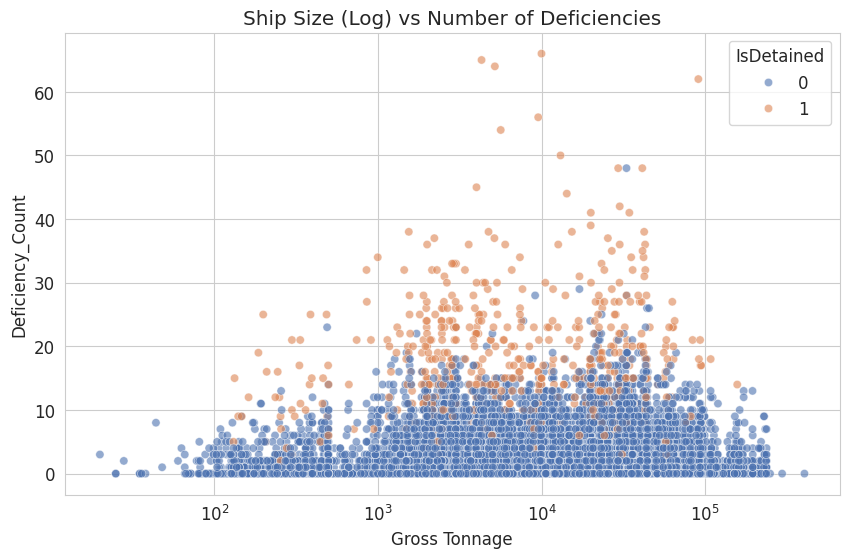

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df2, x='Gross Tonnage', y='Deficiency_Count', hue='IsDetained', alpha=0.6, palette='deep')
plt.xscale('log')
plt.title('Ship Size (Log) vs Number of Deficiencies')
plt.show()

## Detention Probability by Ship Size (Gross Tonnage)

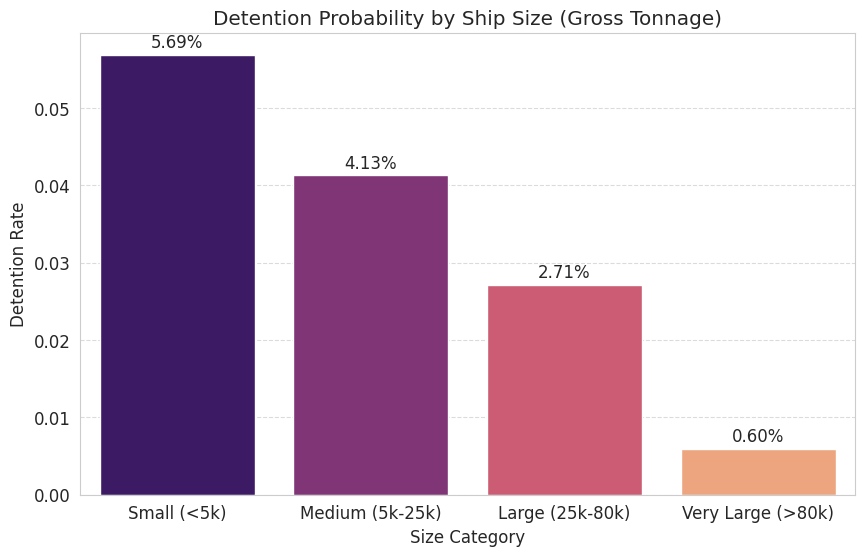

In [ ]:
bins = [0, 5000, 25000, 80000, df2['Gross Tonnage'].max() +1]
labels = ['Small (<5k)', 'Medium (5k-25k)', 'Large (25k-80k)', 'Very Large (>80k)']


df2['Size_Category'] = pd.cut(df2['Gross Tonnage'], bins=bins, labels=labels, include_lowest=True)


size_risk = df2.groupby('Size_Category')['IsDetained'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=size_risk, x='Size_Category', y='IsDetained', palette='magma')


for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2%'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('Detention Probability by Ship Size (Gross Tonnage)')
plt.ylabel('Detention Rate')
plt.xlabel('Size Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Probability of a New Detention based on History (last 36 months)

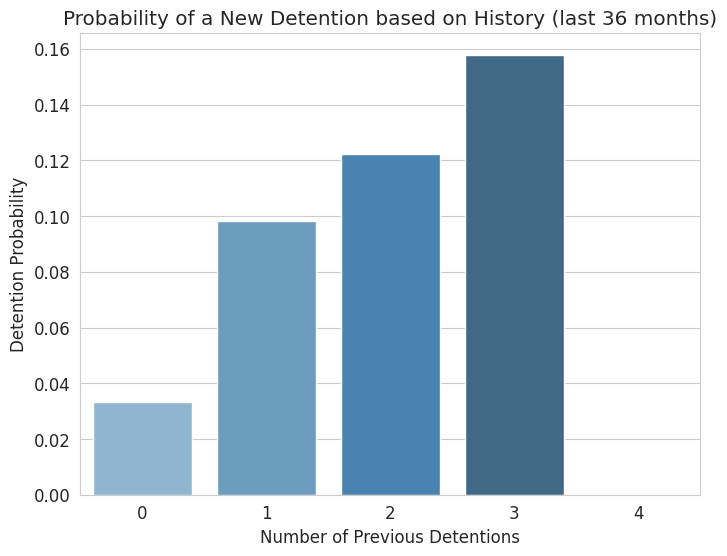

In [ ]:
plt.figure(figsize=(8, 6))

sns.barplot(data=df2, x='Detention < 36 months', y='IsDetained', palette='Blues_d', errorbar=None)
plt.title('Probability of a New Detention based on History (last 36 months)')
plt.xlabel('Number of Previous Detentions')
plt.ylabel('Detention Probability')
plt.show()

## Detentions by Recognized Organisation Performance (RO Performance)

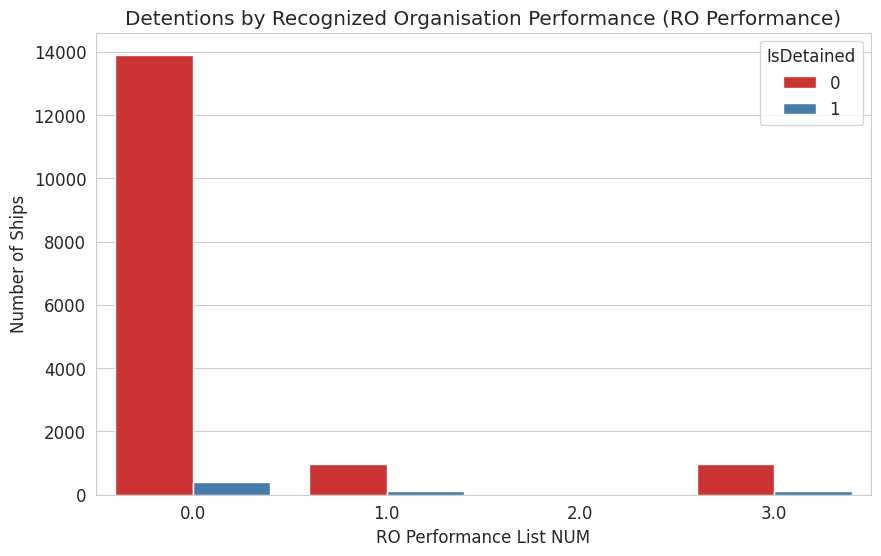

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df2, x='RO Performance List NUM', hue='IsDetained', palette='Set1')
plt.title('Detentions by Recognized Organisation Performance (RO Performance)')
# plt.yscale('log')
plt.ylabel('Number of Ships')
plt.show()

## Top 15 Most Strict Countries (Reporting Countries)

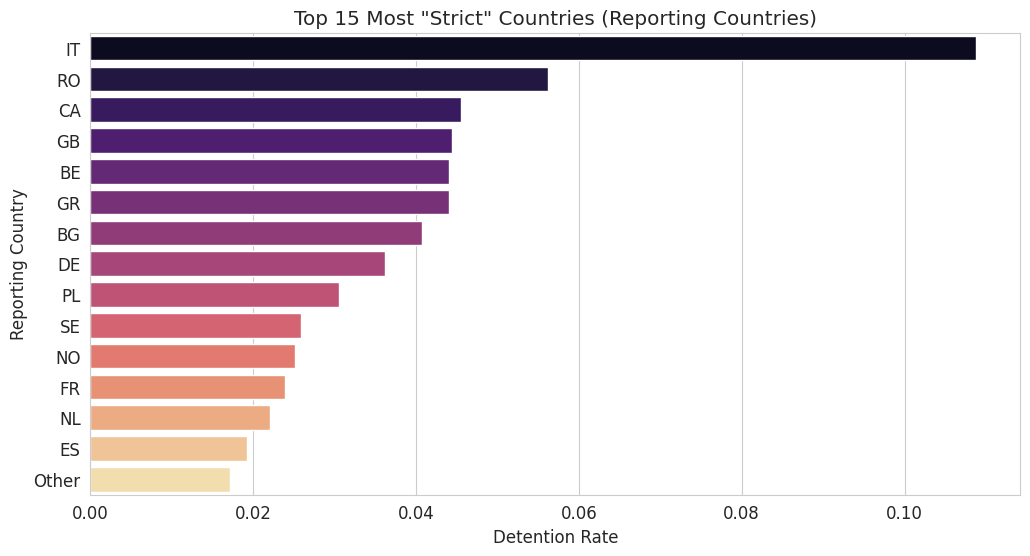

In [ ]:
top_countries = df2['Reporting Country'].value_counts()
valid_countries = top_countries[top_countries > 100].index

country_risk = df2[df2['Reporting Country'].isin(valid_countries)].groupby('Reporting Country')['IsDetained'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_risk.values, y=country_risk.index, palette='magma')
plt.title('Top 15 Most "Strict" Countries (Reporting Countries)')
plt.xlabel('Detention Rate')
plt.show()

## Detention Probability: Combination of Age & Flag

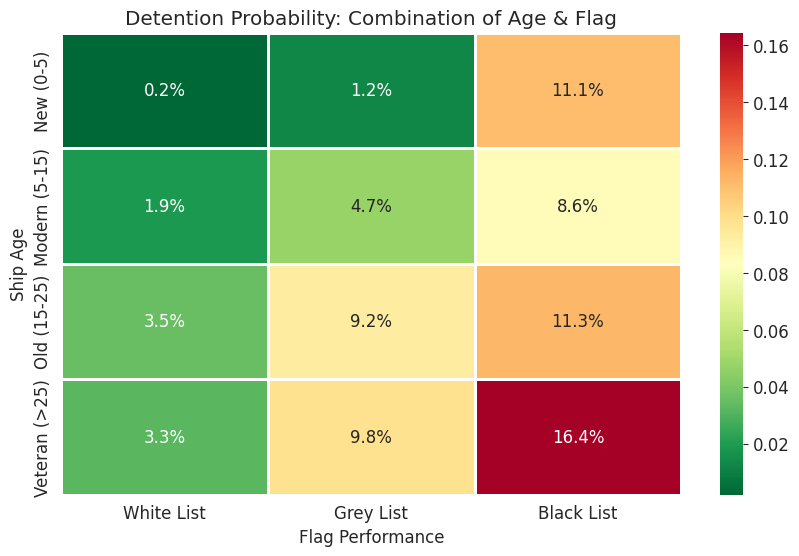

In [ ]:
risk_matrix = df2.pivot_table(index='Age_Category',
                              columns='Flag Performance List NUM',
                              values='IsDetained',
                              aggfunc='mean')


risk_matrix.columns = ['White List', 'Grey List', 'Black List']

plt.figure(figsize=(10, 6))
sns.heatmap(risk_matrix, annot=True, fmt=".1%", cmap='RdYlGn_r', linewidths=1)
plt.title('Detention Probability: Combination of Age & Flag')
plt.ylabel('Ship Age')
plt.xlabel('Flag Performance')
plt.show()

## Distribution of Deficiency History (36 months) per Detention

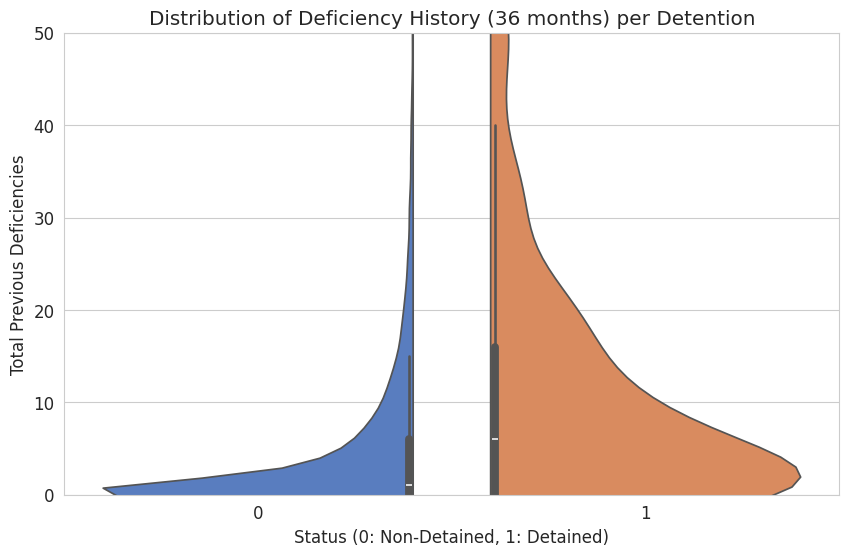

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df2, x='IsDetained', y='Total Defficiencies in 36months', palette='muted', split=True)
plt.title('Distribution of Deficiency History (36 months) per Detention')
plt.xlabel('Status (0: Non-Detained, 1: Detained)')
plt.ylabel('Total Previous Deficiencies')

plt.ylim(0, 50)
plt.show()

## Top 10 Most "Strict" Ports (with >50 inspections)

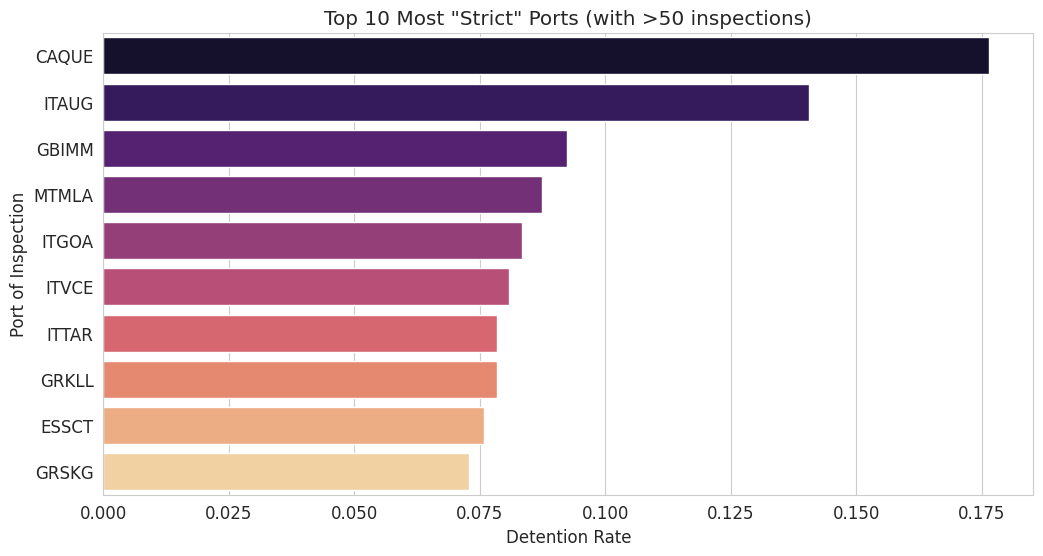

In [ ]:
port_stats = df2.groupby('Port of Inspection').agg(
    Count=('IsDetained', 'count'),
    Detention_Rate=('IsDetained', 'mean')
)
risky_ports = port_stats[port_stats['Count'] > 50].sort_values(by='Detention_Rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=risky_ports['Detention_Rate'], y=risky_ports.index, palette='magma')
plt.title('Top 10 Most "Strict" Ports (with >50 inspections)')
plt.xlabel('Detention Rate')
plt.show()

## Sorted Correlation Matrix (Spearman) based on correlation with IsDetained

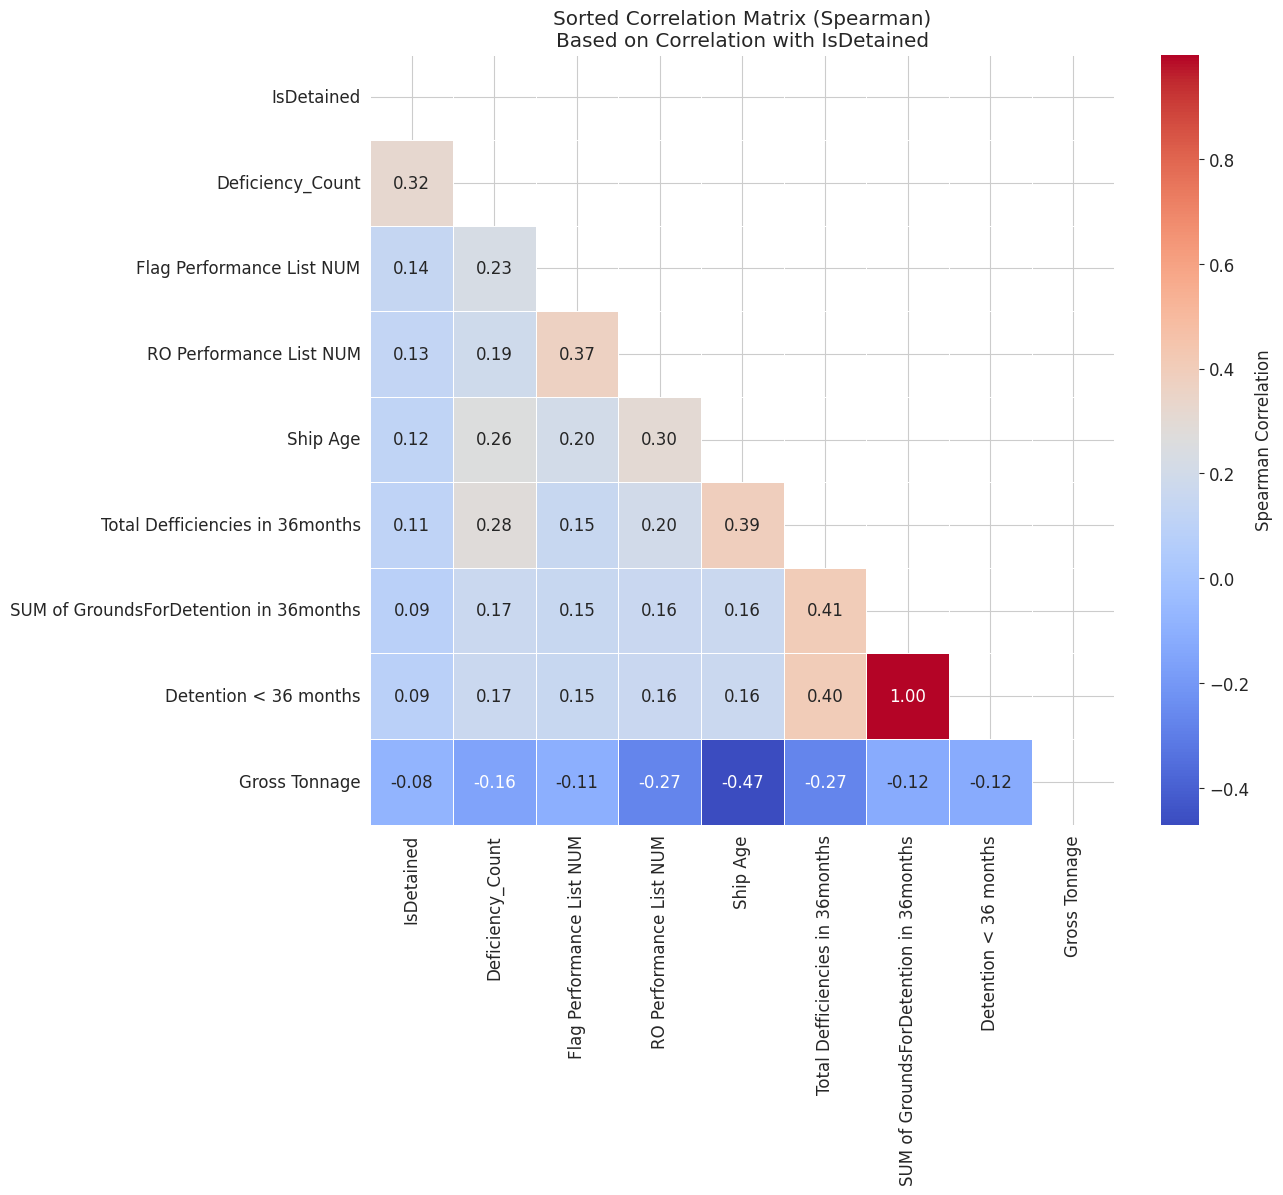

In [ ]:
num_cols = df2.select_dtypes(include=['number']).columns
corr_matrix = df2[num_cols].corr(method='spearman')


sorted_indices = corr_matrix['IsDetained'].sort_values(ascending=False).index
corr_sorted = corr_matrix.loc[sorted_indices, sorted_indices]

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_sorted, dtype=bool))

sns.heatmap(corr_sorted,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            mask=mask,
            cbar_kws={'label': 'Spearman Correlation'})

plt.title('Sorted Correlation Matrix (Spearman)\nBased on Correlation with IsDetained')
plt.show()

# Conclusions

The thorough Exploratory Data Analysis (EDA) demonstrated the need for specific interventions in the variable structure, in order to avoid overfitting and optimize the model's generalization capability. Specifically, it was deemed necessary to merge rare values in High Cardinality variables —such as Port of Inspection and Reporting Country— as the multitude of unique values would create noise during encoding. At the same time, the conversion of the continuous numerical variables `Ship Age` and `Gross Tonnage` into categories (binning) proved critical, as it revealed non-linear risk patterns (e.g., increased detention probability at older age limits) that were not discernible in their original form.

Additionally, the Correlation Analysis identified strong multicollinearity between the variables recording the ship's history, and specifically between `Detention < 36 months` and `SUM of GroundsForDetention in 36 months`. To eliminate information redundancy, only one of the two will be retained in the final dataset, namely `SUM of GroundsForDetention in 36 months`. Although the visualization highlighted the strong predictive capability of other features as well (such as Flag Performance and Ship Type), this section focuses on the structural changes required for the optimal training of the algorithms.

Therefore, the dataset is shaped as follows:

In [ ]:
final_features = [
    'Reporting Country',
    'Port of Inspection',
    'Ship Flag',
    'Flag Performance List NUM',
    'Description',
    'Age_Category',
    'Size_Category',
    'Recognised Organisation (RO)',
    'RO Performance List NUM',
    'Total Defficiencies in 36months',
    'SUM of GroundsForDetention in 36months',
    'Deficiency_Count',
    'IsDetained'
]

final_df = df2[final_features].copy()

In [ ]:
final_df.head()

,Reporting Country,Port of Inspection,Ship Flag,Flag Performance List NUM,Description,Age_Category,Size_Category,Recognised Organisation (RO),RO Performance List NUM,Total Defficiencies in 36months,SUM of GroundsForDetention in 36months,Deficiency_Count,IsDetained
0,NO,Other,NL,0,Warship,Modern (5-15),Medium (5k-25k),115,0.0,2,0,0,0
1,NL,NLAMS,PA,1,Warship,Modern (5-15),Medium (5k-25k),169,0.0,1,0,4,0
2,NL,NLRTM,LR,0,Warship,Modern (5-15),Large (25k-80k),121,0.0,1,0,9,0
3,NL,NLRTM,GR,0,Tanker,Old (15-25),Very Large (>80k),160,0.0,1,0,2,0
4,NL,NLAMS,LR,0,Warship,Modern (5-15),Medium (5k-25k),128,0.0,0,0,0,0


We saw that the categorization of Age and Gross Tonnage reveals patterns that correlate these variables with the detention probability. For this reason, we will transform them from continuous numerical values into categorical ones, and we will keep these in the final dataset that will be used for the development of machine learning models.

In [ ]:
age_mapping = {
    'New (0-5)': 1,
    'Modern (5-15)': 2,
    'Old (15-25)': 3,
    'Veteran (>25)': 4
}

final_df['Age_Category'] = final_df['Age_Category'].map(age_mapping)

print(final_df['Age_Category'].value_counts())

final_df['Age_Category'] = final_df['Age_Category'].astype(int)

Age_Category
2    7441
3    5055
4    2881
1    1137
Name: count, dtype: int64


In [ ]:
size_mapping = {
    'Small (<5k)': 1,
    'Medium (5k-25k)': 2,
    'Large (25k-80k)': 3,
    'Very Large (>80k)': 4
}

final_df['Size_Category'] = final_df['Size_Category'].map(size_mapping)

print(final_df['Size_Category'].value_counts())

final_df['Size_Category'] = final_df['Size_Category'].astype(int)

Size_Category
3    5241
2    5159
1    4604
4    1510
Name: count, dtype: int64


In [ ]:
new_file_name = 'final_cleaned_dataset.csv'

final_df.to_csv(new_file_name, index=False)